# 🌸 Iris Flower Classification

### Project Information

- **Project Name:** Iris Flower Classification
- **Project Type:** Classification
- **Industry:** Oasis Infobyte
- **Contribution:** Individual
- **Member Name:** Arindam Paul
- **Task:** Task 1

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold

# Library used for ML Model implementation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

# Library used for ignore warnings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### Data set loading from sklearn.datasets.load_iris()


In [2]:
import sklearn.datasets
iris = sklearn.datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [3]:
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
# Dataset Rows & Columns count
# Checking number of rows and columns of the dataset using shape
print("Number of rows are: ",df.shape[0])
print("Number of columns are: ",df.shape[1])

Number of rows are:  150
Number of columns are:  5


In [6]:

# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'number of duplicated rows are {dup}')

number of duplicated rows are 1


In [7]:
#remove duplicate rows from the dataset
df2 = df
df2.drop_duplicates(inplace=True)
dup = df2.duplicated().sum()
print(f'number of duplicated rows are {dup}')
print(f'number of non-duplicated rows are {df2.shape[0]}')

number of duplicated rows are 0
number of non-duplicated rows are 149


In [8]:
# Missing Values/Null Values Count
df2.isnull().sum()
     

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

### Understanding The Variables

In [9]:
# Dataset Columns
df2.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [10]:
# Dataset Describe (all columns included)
df2.describe(include= 'all').round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,149.00,149.00,149.00,149.00,149.00
mean,5.84,3.06,3.75,1.19,0.99
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.30,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [11]:
#check unique values in the target column
for i in df2.columns.tolist():
  print("No. of unique values in",i,"is",df2[i].nunique())

No. of unique values in sepal length (cm) is 35
No. of unique values in sepal width (cm) is 23
No. of unique values in petal length (cm) is 43
No. of unique values in petal width (cm) is 22
No. of unique values in target is 3


Data Wrangling

In [12]:

# We don't need the 1st column so let's drop that
data=df2

# New updated dataset
data.head()

data.target.value_counts()

data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Data Visualisation

In [13]:
print(df.columns[1])

sepal width (cm)


Chart - 1 : Distribution of Numerical Variables

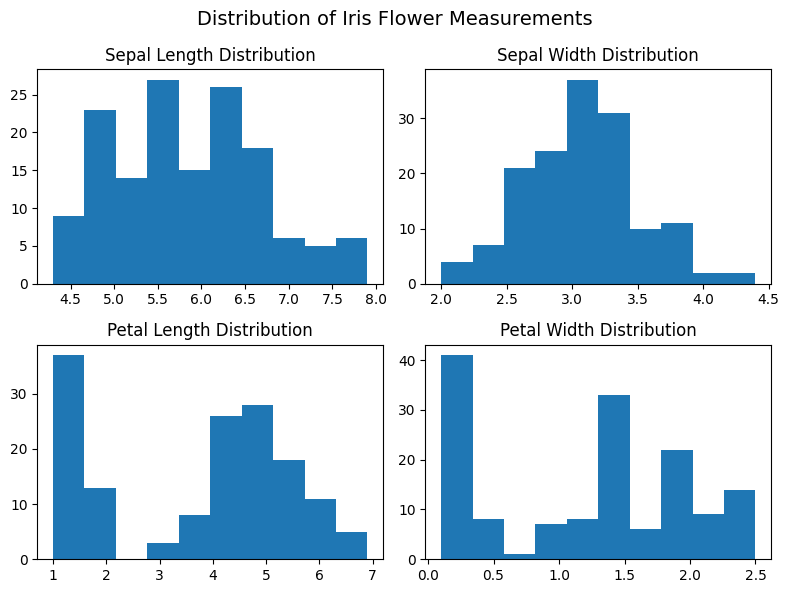

In [14]:
# Chart - 1 Histogram visualization code for distribution of numerical variables
# Create a figure with subplots
plt.figure(figsize=(8, 6))
plt.suptitle('Distribution of Iris Flower Measurements', fontsize=14)

# Create a 2x2 grid of subplots
plt.subplot(2, 2, 1)  # Subplot 1 (Top-Left)
plt.hist(data['sepal length (cm)'])  
plt.title('Sepal Length Distribution')

plt.subplot(2, 2, 2)  # Subplot 2 (Top-Right)
plt.hist(data['sepal width (cm)'])
plt.title('Sepal Width Distribution')

plt.subplot(2, 2, 3)  # Subplot 3 (Bottom-Left)
plt.hist(data['petal length (cm)'])
plt.title('Petal Length Distribution')

plt.subplot(2, 2, 4)  # Subplot 4 (Bottom-Right)
plt.hist(data['petal width (cm)'])
plt.title('Petal Width Distribution')

# Display the subplots
plt.tight_layout()  # Helps in adjusting the layout
plt.show()
     


Chart - 2 : Sepal Length vs Sepal Width

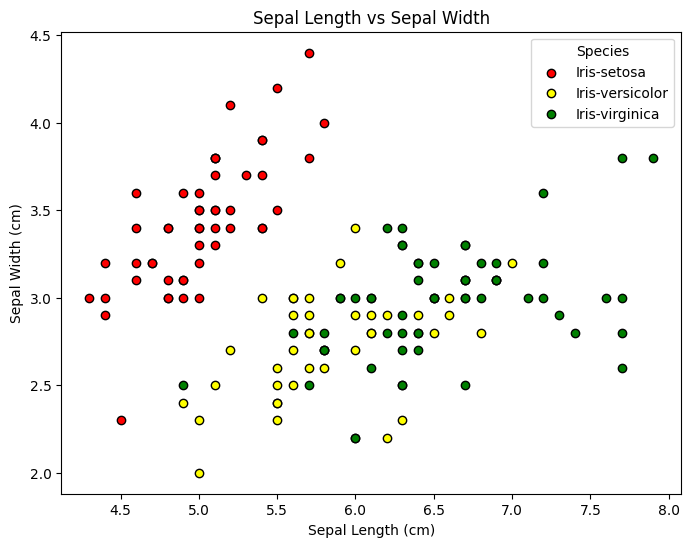

In [15]:
# Define colors, species labels, and matching integer targets
colors = ['red', 'yellow', 'green']
species = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
targets = [0, 1, 2] 

plt.figure(figsize=(8, 6))

for i in range(3):
    # Filter dataframe using the integer targets list
    x = df[df['target'] == targets[i]]
    
    # Plot using species[i] for the legend label
    plt.scatter(x['sepal length (cm)'], x['sepal width (cm)'], c=colors[i], label=species[i], edgecolor='black')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.legend(title="Species")
plt.show()

 Petal Length vs Petal Width

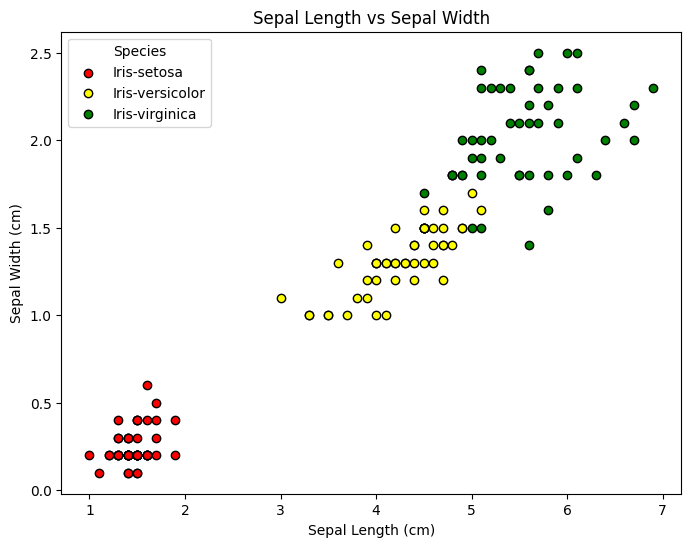

In [16]:
# Define colors, species labels, and matching integer targets
colors = ['red', 'yellow', 'green']
species = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
targets = [0, 1, 2] 

plt.figure(figsize=(8, 6))

for i in range(3):
    # Filter dataframe using the integer targets list
    x = df[df['target'] == targets[i]]
    
    # Plot using species[i] for the legend label
    plt.scatter(x['petal length (cm)'], x['petal width (cm)'], c=colors[i], label=species[i], edgecolor='black')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.legend(title="Species")
plt.show()

Sepal Length vs Petal Length

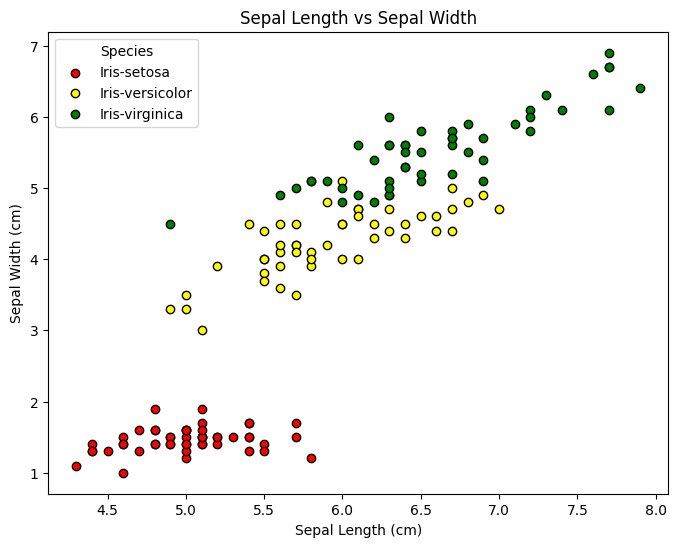

In [17]:
# Define colors, species labels, and matching integer targets
colors = ['red', 'yellow', 'green']
species = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
targets = [0, 1, 2] 

plt.figure(figsize=(8, 6))

for i in range(3):
    # Filter dataframe using the integer targets list
    x = df[df['target'] == targets[i]]
    
    # Plot using species[i] for the legend label
    plt.scatter(x['sepal length (cm)'], x['petal length (cm)'], c=colors[i], label=species[i], edgecolor='black')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.legend(title="Species")
plt.show()

Sepal Width vs Petal Width

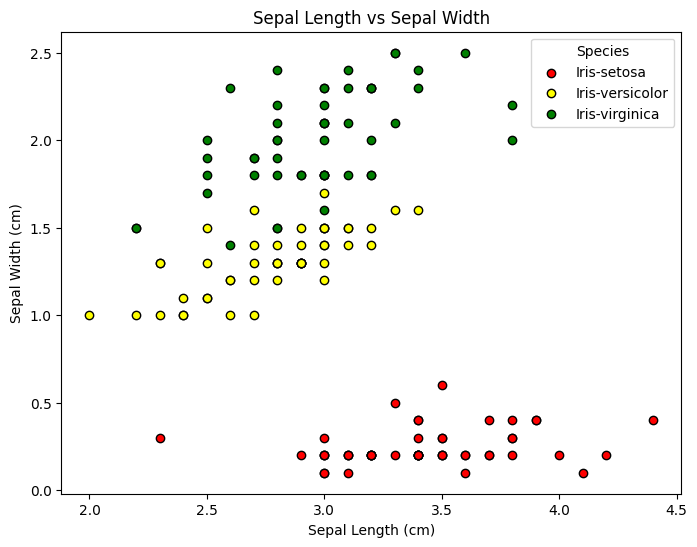

In [18]:
# Define colors, species labels, and matching integer targets
colors = ['red', 'yellow', 'green']
species = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
targets = [0, 1, 2] 

plt.figure(figsize=(8, 6))

for i in range(3):
    # Filter dataframe using the integer targets list
    x = df[df['target'] == targets[i]]
    
    # Plot using species[i] for the legend label
    plt.scatter(x['sepal width (cm)'], x['petal width (cm)'], c=colors[i], label=species[i], edgecolor='black')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.legend(title="Species")
plt.show()

Correlation Heatmap

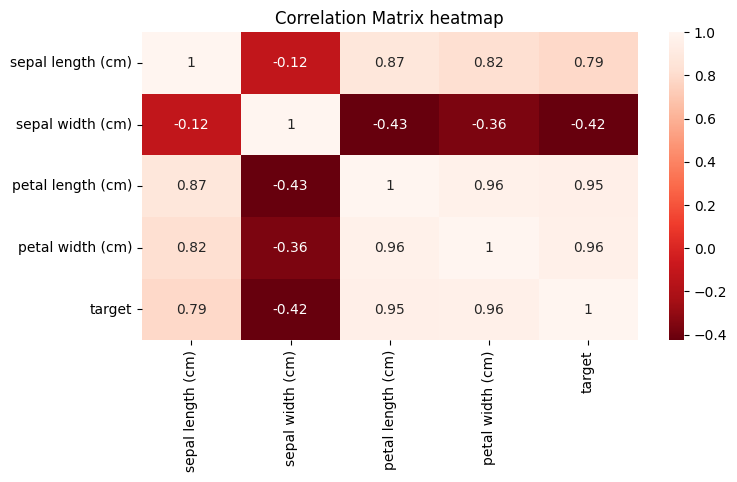

In [19]:

# Correlation Heatmap Visualization Code
corr_matrix = data.corr()

# Plot Heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix, annot=True, cmap='Reds_r')

# Setting Labels
plt.title('Correlation Matrix heatmap')

# Display Chart
plt.show()
     

## Feature Engineering & Data Pre-processing

Data Scaling

In [20]:
# Check the unique values in the 'Species' column after encoding
unique_species = data['target'].unique()

# Display the unique value i target group 

print(unique_species)

[0 1 2]


In [21]:
# Defining the X and y
x=data.drop(columns=['target'], axis=1)
y=data['target']

Data Splitting

In [22]:
# Splitting the data to train and test
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.3)
     

# Checking the train distribution of dependent variable
y_train.value_counts()

target
2    37
1    37
0    30
Name: count, dtype: int64

## ML Model Implementation

In [23]:
def evaluate_model(model, x_train, x_test, y_train, y_test):
    '''The function will take model, x train, x test, y train, y test
    and then it will fit the model, then make predictions on the trained model,
    it will then print roc-auc score of train and test, then plot the roc, auc curve,
    print confusion matrix for train and test, then print classification report for train and test,
    then plot the feature importances if the model has feature importances,
    and finally it will return the following scores as a list:
    recall_train, recall_test, acc_train, acc_test, F1_train, F1_test
    '''

    # Fit the model to the training data.
    model.fit(x_train, y_train)

    # make predictions on the test data
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    # calculate confusion matrix
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)

    fig, ax = plt.subplots(1, 2, figsize=(11,4))

    print("\nConfusion Matrix:")
    sns.heatmap(cm_train, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[0])
    ax[0].set_xlabel("Predicted Label")
    ax[0].set_ylabel("True Label")
    ax[0].set_title("Train Confusion Matrix")

    sns.heatmap(cm_test, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[1])
    ax[1].set_xlabel("Predicted Label")
    ax[1].set_ylabel("True Label")
    ax[1].set_title("Test Confusion Matrix")

    plt.tight_layout()
    plt.show()


    # calculate classification report
    cr_train = classification_report(y_train, y_pred_train, output_dict=True)
    cr_test = classification_report(y_test, y_pred_test, output_dict=True)
    print("\nTrain Classification Report:")
    crt = pd.DataFrame(cr_train).T
    print(crt.to_markdown())
    # sns.heatmap(pd.DataFrame(cr_train).T.iloc[:, :-1], annot=True, cmap="Blues")
    print("\nTest Classification Report:")
    crt2 = pd.DataFrame(cr_test).T
    print(crt2.to_markdown())
    # sns.heatmap(pd.DataFrame(cr_test).T.iloc[:, :-1], annot=True, cmap="Blues")

    precision_train = cr_train['weighted avg']['precision']
    precision_test = cr_test['weighted avg']['precision']

    recall_train = cr_train['weighted avg']['recall']
    recall_test = cr_test['weighted avg']['recall']

    acc_train = accuracy_score(y_true = y_train, y_pred = y_pred_train)
    acc_test = accuracy_score(y_true = y_test, y_pred = y_pred_test)

    F1_train = cr_train['weighted avg']['f1-score']
    F1_test = cr_test['weighted avg']['f1-score']

    model_score = [precision_train, precision_test, recall_train, recall_test, acc_train, acc_test, F1_train, F1_test ]
    return model_score
     

In [24]:
# Create a score dataframe
score = pd.DataFrame(index = ['Precision Train', 'Precision Test','Recall Train','Recall Test','Accuracy Train', 'Accuracy Test', 'F1 macro Train', 'F1 macro Test'])
     


## ML Model - 1 : Logistic regression

In [25]:

# ML Model - 1 Implementation
lr_model = LogisticRegression(fit_intercept=True, max_iter=10000)

# Model is trained (fit) and predicted in the evaluate model

1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


Confusion Matrix:


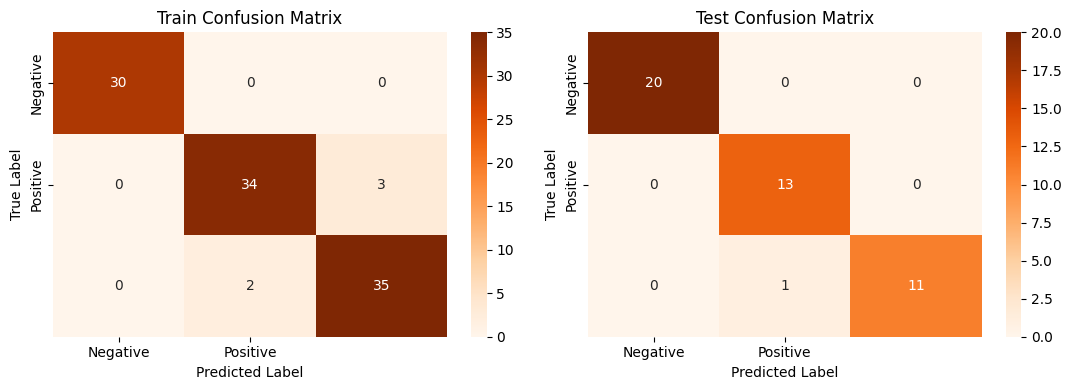


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  30        |
| 1            |    0.944444 | 0.918919 |   0.931507 |  37        |
| 2            |    0.921053 | 0.945946 |   0.933333 |  37        |
| accuracy     |    0.951923 | 0.951923 |   0.951923 |   0.951923 |
| macro avg    |    0.955166 | 0.954955 |   0.954947 | 104        |
| weighted avg |    0.952148 | 0.951923 |   0.951914 | 104        |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 20        |
| 1            |    0.928571 | 1        |   0.962963 | 13        |
| 2            |    1        | 0.916667 |   0.956522 | 12        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.9777

In [26]:

# Visualizing evaluation Metric Score chart
lr_score = evaluate_model(lr_model, x_train, x_test, y_train, y_test)
     

In [27]:
# Updated Evaluation metric Score Chart
score['Logistic regression'] = lr_score
score

,Logistic regression
Precision Train,0.952148
Precision Test,0.979365
Recall Train,0.951923
Recall Test,0.977778
Accuracy Train,0.951923
Accuracy Test,0.977778
F1 macro Train,0.951914
F1 macro Test,0.977706


2. Cross- Validation & Hyperparameter Tuning

In [28]:


# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Define the hyperparameter grid
param_grid = {'C': [100,10,1,0.1,0.01,0.001,0.0001],
              'penalty': ['l1', 'l2'],
              'solver':['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Initializing the logistic regression model
logreg = LogisticRegression(fit_intercept=True, max_iter=10000, random_state=0)

# Repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=4, random_state=0)

# Using GridSearchCV to tune the hyperparameters using cross-validation
grid = GridSearchCV(logreg, param_grid, cv=rskf)
grid.fit(x_train, y_train)

# Select the best hyperparameters found by GridSearchCV
best_params = grid.best_params_
print("Best hyperparameters: ", best_params)

Best hyperparameters:  {'C': 10, 'penalty': 'l2', 'solver': 'saga'}


In [29]:
# Initiate model with best parameters
lr_model2 = LogisticRegression(C=best_params['C'],
                                  penalty=best_params['penalty'],
                                  solver=best_params['solver'],
                                  max_iter=10000, random_state=0)


Confusion Matrix:


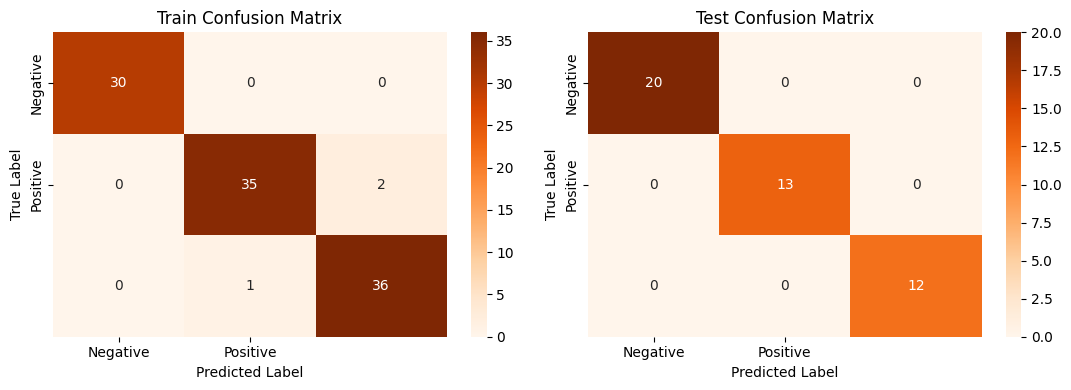


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  30        |
| 1            |    0.972222 | 0.945946 |   0.958904 |  37        |
| 2            |    0.947368 | 0.972973 |   0.96     |  37        |
| accuracy     |    0.971154 | 0.971154 |   0.971154 |   0.971154 |
| macro avg    |    0.973197 | 0.972973 |   0.972968 | 104        |
| weighted avg |    0.971393 | 0.971154 |   0.971149 | 104        |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        20 |
| 1            |           1 |        1 |          1 |        13 |
| 2            |           1 |        1 |          1 |        12 |
| accuracy     |           1 |        1 |          1 |        

In [30]:

# Visualizing evaluation Metric Score chart
lr_score2 = evaluate_model(lr_model2, x_train, x_test, y_train, y_test)

In [31]:

# Updated Evaluation metric Score Chart
score

,Logistic regression
Precision Train,0.952148
Precision Test,0.979365
Recall Train,0.951923
Recall Test,0.977778
Accuracy Train,0.951923
Accuracy Test,0.977778
F1 macro Train,0.951914
F1 macro Test,0.977706


For this model, I used **GridSearchCV** for hyperparameter optimization. I chose this approach because it systematically runs an exhaustive search through a predefined grid of parameters to lock down the optimal configuration. It is straightforward to implement and generally very reliable. Since the parameter space I was working with was relatively small and I had enough computational resources to handle the workload without strict time constraints, an exhaustive search like GridSearchCV made the most sense.

**Did the model improve?**

Actually, no. The hyperparameter tuning did not improve the performance of the Logistic Regression model on the test set. As you can see in the evaluation metrics above, the tuned model returned the exact same precision, recall, accuracy, and F1 scores as the base, untuned model.

## ML Model - 2 : Decision Tree

In [32]:
# ML Model - 2 Implementation
dt_model = DecisionTreeClassifier(random_state=20)

# Model is trained (fit) and predicted in the evaluate model

1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


Confusion Matrix:


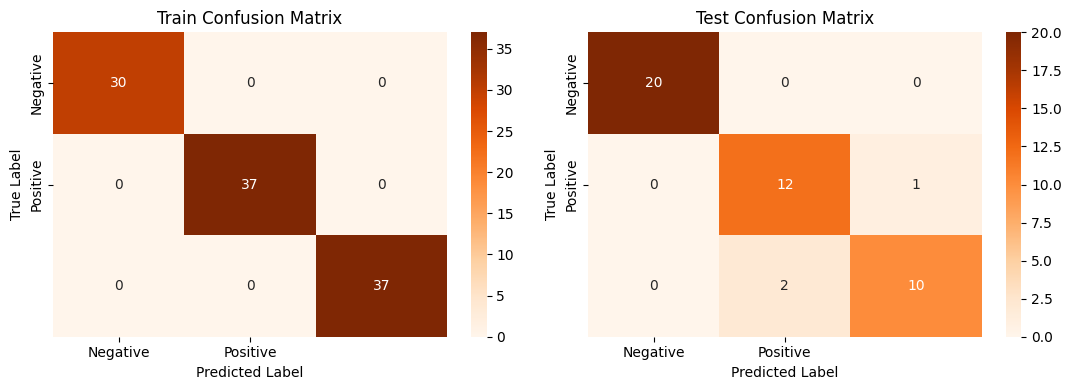


Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        30 |
| 1            |           1 |        1 |          1 |        37 |
| 2            |           1 |        1 |          1 |        37 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       104 |
| weighted avg |           1 |        1 |          1 |       104 |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 20        |
| 1            |    0.857143 | 0.923077 |   0.888889 | 13        |
| 2            |    0.909091 | 0.833333 |   0.869565 | 12        |
| accuracy     |    0.933333 | 0.933333 |   0.933333 |  0.933333 |
| m

In [33]:

# Visualizing evaluation Metric Score chart
dt_score = evaluate_model(dt_model, x_train, x_test, y_train, y_test)

In [34]:
# Updated Evaluation metric Score Chart
score['Decision Tree'] = dt_score
score

,Logistic regression,Decision Tree
Precision Train,0.952148,1.000000
Precision Test,0.979365,0.934488
Recall Train,0.951923,1.000000
Recall Test,0.977778,0.933333
Accuracy Train,0.951923,1.000000
Accuracy Test,0.977778,0.933333
F1 macro Train,0.951914,1.000000
F1 macro Test,0.977706,0.933119


2. Cross- Validation & Hyperparameter Tuning

In [35]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Define the hyperparameter grid
grid = {'max_depth' : [3,4,5,6,7,8],
        'min_samples_split' : np.arange(2,8),
        'min_samples_leaf' : np.arange(10,20)}

# Initialize the model
model = DecisionTreeClassifier()

# repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=0)

# Initialize GridSearchCV
grid_search = GridSearchCV(model, grid, cv=rskf)

# Fit the GridSearchCV to the training data
grid_search.fit(x_train, y_train)

# Select the best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters: ", best_params)

Best hyperparameters:  {'max_depth': 3, 'min_samples_leaf': np.int64(10), 'min_samples_split': np.int64(5)}


In [36]:
# Train a new model with the best hyperparameters
dt_model2 = DecisionTreeClassifier(max_depth=best_params['max_depth'],
                                 min_samples_leaf=best_params['min_samples_leaf'],
                                 min_samples_split=best_params['min_samples_split'],
                                 random_state=20)
     


Confusion Matrix:


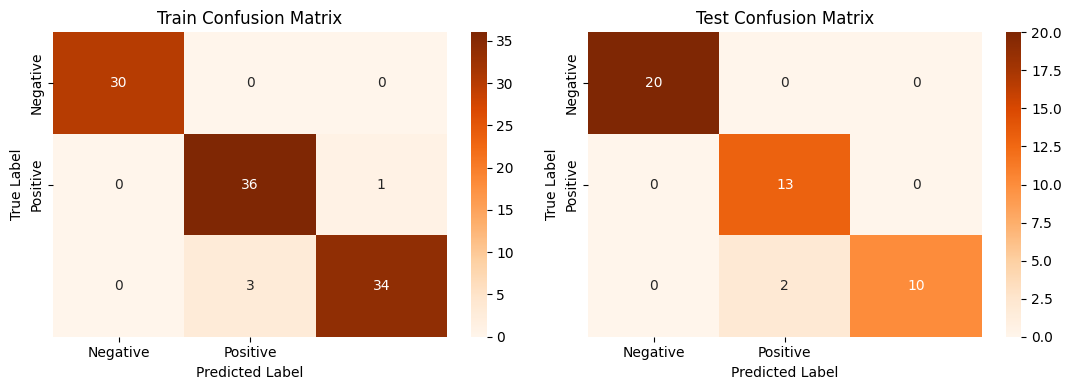


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  30        |
| 1            |    0.923077 | 0.972973 |   0.947368 |  37        |
| 2            |    0.971429 | 0.918919 |   0.944444 |  37        |
| accuracy     |    0.961538 | 0.961538 |   0.961538 |   0.961538 |
| macro avg    |    0.964835 | 0.963964 |   0.963938 | 104        |
| weighted avg |    0.962468 | 0.961538 |   0.96151  | 104        |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 20        |
| 1            |    0.866667 | 1        |   0.928571 | 13        |
| 2            |    1        | 0.833333 |   0.909091 | 12        |
| accuracy     |    0.955556 | 0.955556 |   0.955556 |  0.9555

In [37]:
# Visualizing evaluation Metric Score chart
dt2_score = evaluate_model(dt_model2, x_train, x_test, y_train, y_test)

In [38]:
score['Decision Tree tuned'] = dt2_score

In [39]:
# Updated Evaluation metric Score Chart
score

,Logistic regression,Decision Tree,Decision Tree tuned
Precision Train,0.952148,1.000000,0.962468
Precision Test,0.979365,0.934488,0.961481
Recall Train,0.951923,1.000000,0.961538
Recall Test,0.977778,0.933333,0.955556
Accuracy Train,0.951923,1.000000,0.961538
Accuracy Test,0.977778,0.933333,0.955556
F1 macro Train,0.951914,1.000000,0.961510
F1 macro Test,0.977706,0.933119,0.955123


Which hyperparameter optimization technique have i used and why?

The hyperparameter optimization technique used is GridSearchCV. GridSearchCV is a method that performs an exhaustive search over a specified parameter grid to find the best hyperparameters for a model. It is a popular method for hyperparameter tuning because it is simple to implement and can be effective in finding good hyperparameters for a model.

The choice of hyperparameter optimization technique depends on various factors such as the size of the parameter space, the computational resources available, and the time constraints. GridSearchCV can be a good choice when the parameter space is relatively small and computational resources are not a major concern.

It appears that hyperparameter tuning didn't improved the performance of the Decision Tree model on the test set. The precision, recall, accuracy and F1 scores on the test set are less for the tuned Decision Tree model compare to the untuned Decision Tree model.

The tuned model is not overfitting like the untuned model.

### ML Model - 3 : Random Forest

In [40]:
# ML Model - 3 Implementation
rf_model = RandomForestClassifier(random_state=0)

# Model is trained (fit) and predicted in the evaluate model

1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


Confusion Matrix:


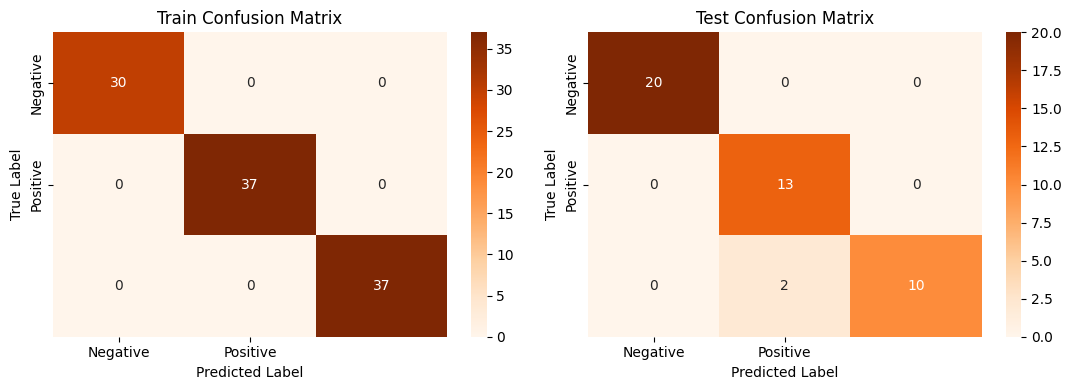


Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        30 |
| 1            |           1 |        1 |          1 |        37 |
| 2            |           1 |        1 |          1 |        37 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       104 |
| weighted avg |           1 |        1 |          1 |       104 |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 20        |
| 1            |    0.866667 | 1        |   0.928571 | 13        |
| 2            |    1        | 0.833333 |   0.909091 | 12        |
| accuracy     |    0.955556 | 0.955556 |   0.955556 |  0.955556 |
| m

In [41]:

# Visualizing evaluation Metric Score chart
rf_score = evaluate_model(rf_model, x_train, x_test, y_train, y_test)

In [42]:
# Updated Evaluation metric Score Chart
score['Random Forest'] = rf_score
score
    

,Logistic regression,Decision Tree,Decision Tree tuned,Random Forest
Precision Train,0.952148,1.000000,0.962468,1.000000
Precision Test,0.979365,0.934488,0.961481,0.961481
Recall Train,0.951923,1.000000,0.961538,1.000000
Recall Test,0.977778,0.933333,0.955556,0.955556
Accuracy Train,0.951923,1.000000,0.961538,1.000000
Accuracy Test,0.977778,0.933333,0.955556,0.955556
F1 macro Train,0.951914,1.000000,0.961510,1.000000
F1 macro Test,0.977706,0.933119,0.955123,0.955123


2. Cross- Validation & Hyperparameter Tuning

In [43]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Define the hyperparameter grid
grid = {'n_estimators': [10, 50, 100, 200],
              'max_depth': [8, 9, 10, 11, 12,13, 14, 15],
              'min_samples_split': [2, 3, 4, 5]}

# Initialize the model
rf = RandomForestClassifier(random_state=0)

# Repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=0)

# Initialize RandomSearchCV
random_search = RandomizedSearchCV(rf, grid,cv=rskf, n_iter=10, n_jobs=-1)

# Fit the RandomSearchCV to the training data
random_search.fit(x_train, y_train)

# Select the best hyperparameters
best_params = random_search.best_params_
print("Best hyperparameters: ", best_params)

Best hyperparameters:  {'n_estimators': 200, 'min_samples_split': 4, 'max_depth': 11}


In [44]:
# Initialize model with best parameters
rf_model2 = RandomForestClassifier(n_estimators = best_params['n_estimators'],
                                 min_samples_leaf= best_params['min_samples_split'],
                                 max_depth = best_params['max_depth'],
                                 random_state=0)


Confusion Matrix:


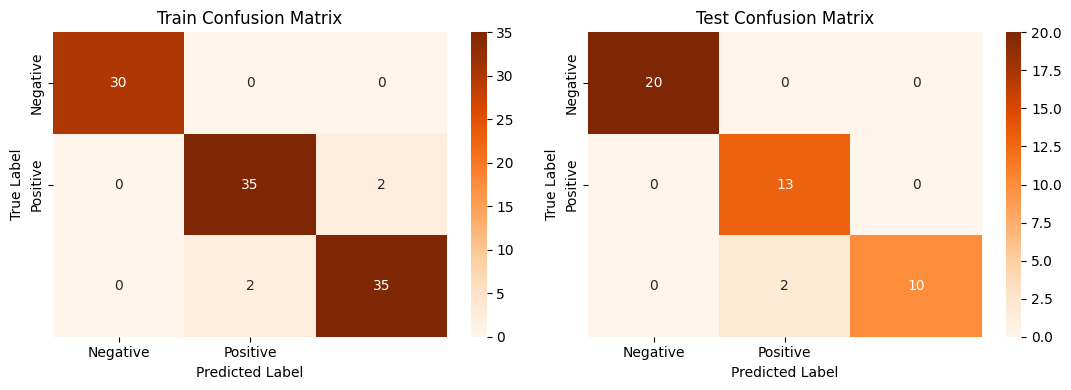


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  30        |
| 1            |    0.945946 | 0.945946 |   0.945946 |  37        |
| 2            |    0.945946 | 0.945946 |   0.945946 |  37        |
| accuracy     |    0.961538 | 0.961538 |   0.961538 |   0.961538 |
| macro avg    |    0.963964 | 0.963964 |   0.963964 | 104        |
| weighted avg |    0.961538 | 0.961538 |   0.961538 | 104        |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 20        |
| 1            |    0.866667 | 1        |   0.928571 | 13        |
| 2            |    1        | 0.833333 |   0.909091 | 12        |
| accuracy     |    0.955556 | 0.955556 |   0.955556 |  0.9555

In [45]:
# Visualizing evaluation Metric Score chart
rf2_score = evaluate_model(rf_model2, x_train, x_test, y_train, y_test)

In [46]:

score['Random Forest tuned'] = rf2_score

In [47]:
# Updated Evaluation metric Score Chart
score

,Logistic regression,Decision Tree,Decision Tree tuned,Random Forest,Random Forest tuned
Precision Train,0.952148,1.000000,0.962468,1.000000,0.961538
Precision Test,0.979365,0.934488,0.961481,0.961481,0.961481
Recall Train,0.951923,1.000000,0.961538,1.000000,0.961538
Recall Test,0.977778,0.933333,0.955556,0.955556,0.955556
Accuracy Train,0.951923,1.000000,0.961538,1.000000,0.961538
Accuracy Test,0.977778,0.933333,0.955556,0.955556,0.955556
F1 macro Train,0.951914,1.000000,0.961510,1.000000,0.961538
F1 macro Test,0.977706,0.933119,0.955123,0.955123,0.955123


The hyperparameter optimization technique i used is RandomizedSearchCV. RandomizedSearchCV is a method that performs a random search over a specified parameter grid to find the best hyperparameters for a model. It is a popular method for hyperparameter tuning because it can be more efficient than exhaustive search methods like GridSearchCV when the parameter space is large.

The choice of hyperparameter optimization technique depends on various factors such as the size of the parameter space, the computational resources available, and the time constraints. RandomizedSearchCV can be a good choice when the parameter space is large and computational resources are limited.

It appears that hyperparameter tuning improved the performance of the Random Forest model on the train set. But the precision, recall, accuracy and F1 scores on the test set are same for both tuned and untuned Random Forest models.

#### ML Model - 4 : SVM (Support Vector Machine)


Confusion Matrix:


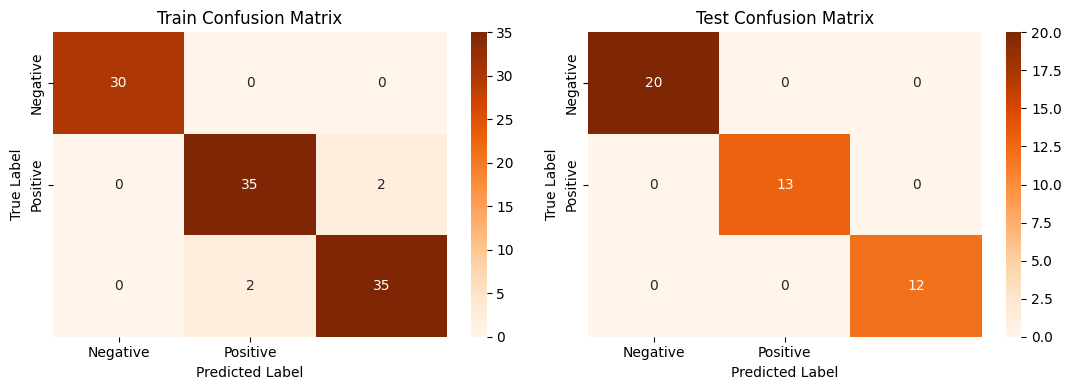


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  30        |
| 1            |    0.945946 | 0.945946 |   0.945946 |  37        |
| 2            |    0.945946 | 0.945946 |   0.945946 |  37        |
| accuracy     |    0.961538 | 0.961538 |   0.961538 |   0.961538 |
| macro avg    |    0.963964 | 0.963964 |   0.963964 | 104        |
| weighted avg |    0.961538 | 0.961538 |   0.961538 | 104        |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        20 |
| 1            |           1 |        1 |          1 |        13 |
| 2            |           1 |        1 |          1 |        12 |
| accuracy     |           1 |        1 |          1 |        

In [48]:
# ML Model - 4 Implementation
svm_model = SVC(kernel='linear', random_state=0, probability=True)

# Model is trained (fit) and predicted in the evaluate model
     


# Visualizing evaluation Metric Score chart
svm_score = evaluate_model(svm_model, x_train, x_test, y_train, y_test)

In [49]:

# Updated Evaluation metric Score Chart
score['SVM'] = svm_score
score

,Logistic regression,Decision Tree,Decision Tree tuned,Random Forest,Random Forest tuned,SVM
Precision Train,0.952148,1.000000,0.962468,1.000000,0.961538,0.961538
Precision Test,0.979365,0.934488,0.961481,0.961481,0.961481,1.000000
Recall Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538
Recall Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000
Accuracy Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538
Accuracy Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000
F1 macro Train,0.951914,1.000000,0.961510,1.000000,0.961538,0.961538
F1 macro Test,0.977706,0.933119,0.955123,0.955123,0.955123,1.000000


Best hyperparameters:  {'kernel': 'linear', 'degree': np.int64(2), 'C': np.float64(3.1)}

Confusion Matrix:


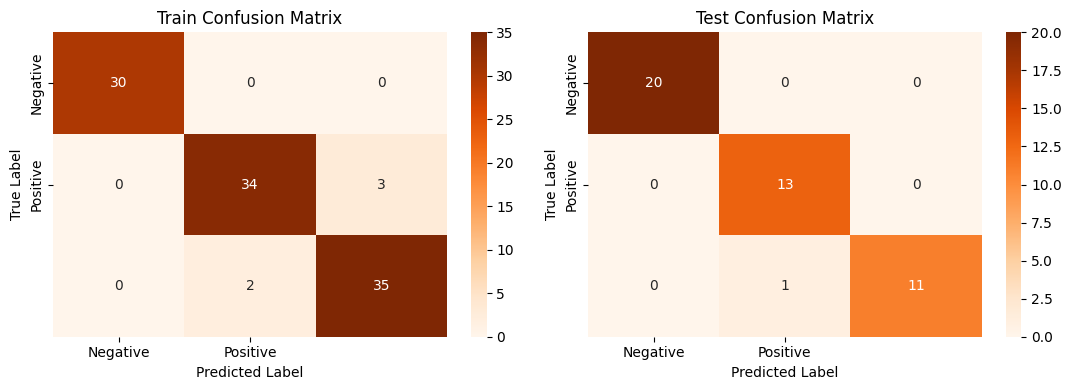


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  30        |
| 1            |    0.944444 | 0.918919 |   0.931507 |  37        |
| 2            |    0.921053 | 0.945946 |   0.933333 |  37        |
| accuracy     |    0.951923 | 0.951923 |   0.951923 |   0.951923 |
| macro avg    |    0.955166 | 0.954955 |   0.954947 | 104        |
| weighted avg |    0.952148 | 0.951923 |   0.951914 | 104        |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 20        |
| 1            |    0.928571 | 1        |   0.962963 | 13        |
| 2            |    1        | 0.916667 |   0.956522 | 12        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.9777

In [50]:
# ML Model - 4 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Define the hyperparameter grid
param_grid = {'C': np.arange(0.1, 10, 0.1),
              'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
              'degree': np.arange(2, 6, 1)}

# Initialize the model
svm = SVC(random_state=0, probability=True)

# Repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=0)

# Initialize RandomizedSearchCV with kfold cross-validation
random_search = RandomizedSearchCV(svm, param_grid, n_iter=10, cv=rskf, n_jobs=-1)

# Fit the RandomizedSearchCV to the training data
random_search.fit(x_train, y_train)

# Select the best hyperparameters
best_params = random_search.best_params_
print("Best hyperparameters: ", best_params)





# Initialize model with best parameters
svm_model2 = SVC(C = best_params['C'],
           kernel = best_params['kernel'],
           degree = best_params['degree'],
           random_state=0, probability=True)



# Visualizing evaluation Metric Score chart
svm2_score = evaluate_model(svm_model2, x_train, x_test, y_train, y_test)

In [51]:
score['SVM tuned'] = svm2_score


# Updated Evaluation metric Score Chart
score
     

,Logistic regression,Decision Tree,Decision Tree tuned,Random Forest,Random Forest tuned,SVM,SVM tuned
Precision Train,0.952148,1.000000,0.962468,1.000000,0.961538,0.961538,0.952148
Precision Test,0.979365,0.934488,0.961481,0.961481,0.961481,1.000000,0.979365
Recall Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538,0.951923
Recall Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000,0.977778
Accuracy Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538,0.951923
Accuracy Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000,0.977778
F1 macro Train,0.951914,1.000000,0.961510,1.000000,0.961538,0.961538,0.951914
F1 macro Test,0.977706,0.933119,0.955123,0.955123,0.955123,1.000000,0.977706


Here Randomized search is used as a hyperparameter optimization technique. Randomized search is a popular technique because it can be more efficient than exhaustive search methods like grid search. Instead of trying all possible combinations of hyperparameters, randomized search samples a random subset of the hyperparameter space. This can save time and computational resources while still finding good hyperparameters for the model.

It appears that hyperparameter tuning did not improve the performance of the SVM model on the test set. The precision, recall, accuracy and F1 scores on the test set are same for both tuned and untuned SVM models

#### ML Model - 5 : Xtreme Gradient Boosting

In [52]:

# ML Model - 5 Implementation
xgb_model = xgb.XGBClassifier()

# Model is trained (fit) and predicted in the evaluate model




Confusion Matrix:


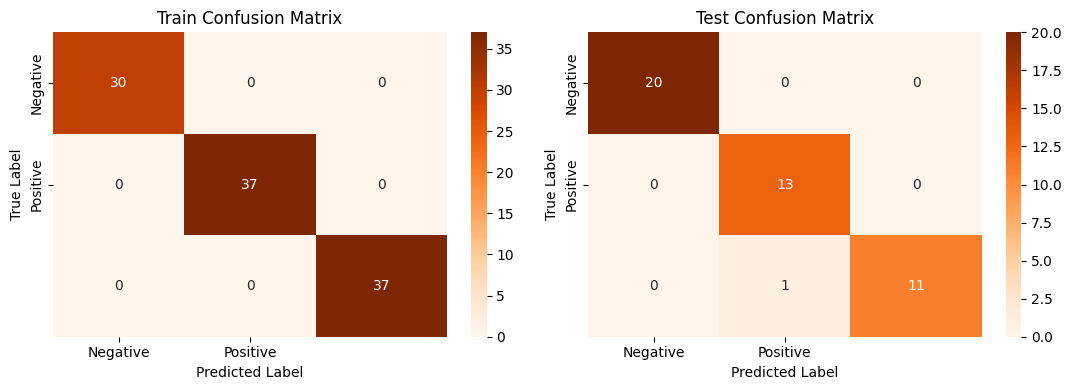


Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        30 |
| 1            |           1 |        1 |          1 |        37 |
| 2            |           1 |        1 |          1 |        37 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       104 |
| weighted avg |           1 |        1 |          1 |       104 |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 20        |
| 1            |    0.928571 | 1        |   0.962963 | 13        |
| 2            |    1        | 0.916667 |   0.956522 | 12        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.977778 |
| m

In [53]:
# Visualizing evaluation Metric Score chart
xgb_score = evaluate_model(xgb_model, x_train, x_test, y_train, y_test)

In [54]:
# Updated Evaluation metric Score Chart
score['XGB'] = xgb_score
score

,Logistic regression,Decision Tree,Decision Tree tuned,Random Forest,Random Forest tuned,SVM,SVM tuned,XGB
Precision Train,0.952148,1.000000,0.962468,1.000000,0.961538,0.961538,0.952148,1.000000
Precision Test,0.979365,0.934488,0.961481,0.961481,0.961481,1.000000,0.979365,0.979365
Recall Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538,0.951923,1.000000
Recall Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000,0.977778,0.977778
Accuracy Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538,0.951923,1.000000
Accuracy Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000,0.977778,0.977778
F1 macro Train,0.951914,1.000000,0.961510,1.000000,0.961538,0.961538,0.951914,1.000000
F1 macro Test,0.977706,0.933119,0.955123,0.955123,0.955123,1.000000,0.977706,0.977706


#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 5 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Define the hyperparameter grid
param_grid = {'learning_rate': np.arange(0.01, 0.3, 0.01),
              'max_depth': np.arange(3, 15, 1),
              'n_estimators': np.arange(100, 200, 10)}

# Initialize the model
xgb2 = xgb.XGBClassifier(random_state=0)

# Repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=0)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(xgb2, param_grid, n_iter=10, cv=rskf)

# Fit the RandomizedSearchCV to the training data
random_search.fit(x_train, y_train)

# Select the best hyperparameters
best_params = random_search.best_params_
print("Best hyperparameters: ", best_params)

Best hyperparameters:  {'n_estimators': np.int64(130), 'max_depth': np.int64(4), 'learning_rate': np.float64(0.01)}



Confusion Matrix:


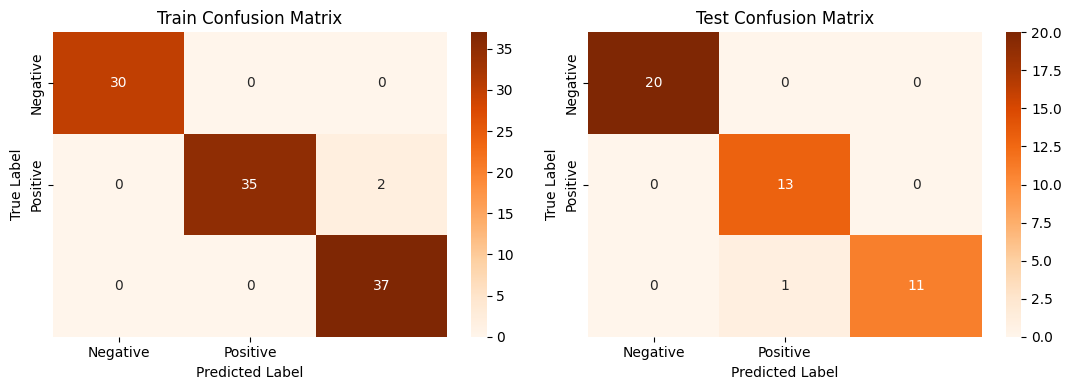


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  30        |
| 1            |    1        | 0.945946 |   0.972222 |  37        |
| 2            |    0.948718 | 1        |   0.973684 |  37        |
| accuracy     |    0.980769 | 0.980769 |   0.980769 |   0.980769 |
| macro avg    |    0.982906 | 0.981982 |   0.981969 | 104        |
| weighted avg |    0.981755 | 0.980769 |   0.980755 | 104        |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 20        |
| 1            |    0.928571 | 1        |   0.962963 | 13        |
| 2            |    1        | 0.916667 |   0.956522 | 12        |
| accuracy     |    0.977778 | 0.977778 |   0.977778 |  0.9777

In [56]:
# Initialize model with best parameters
xgb_model2 = xgb.XGBClassifier(learning_rate = best_params['learning_rate'],
                                 max_depth = best_params['max_depth'],
                               n_estimators = best_params['n_estimators'],
                                 random_state=0)
     

# Visualizing evaluation Metric Score chart
xgb2_score = evaluate_model(xgb_model2, x_train, x_test, y_train, y_test)

In [57]:
score['XGB tuned'] = xgb2_score

In [58]:
# Updated Evaluation metric Score Chart
score

,Logistic regression,Decision Tree,Decision Tree tuned,Random Forest,Random Forest tuned,SVM,SVM tuned,XGB,XGB tuned
Precision Train,0.952148,1.000000,0.962468,1.000000,0.961538,0.961538,0.952148,1.000000,0.981755
Precision Test,0.979365,0.934488,0.961481,0.961481,0.961481,1.000000,0.979365,0.979365,0.979365
Recall Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538,0.951923,1.000000,0.980769
Recall Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000,0.977778,0.977778,0.977778
Accuracy Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538,0.951923,1.000000,0.980769
Accuracy Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000,0.977778,0.977778,0.977778
F1 macro Train,0.951914,1.000000,0.961510,1.000000,0.961538,0.961538,0.951914,1.000000,0.980755
F1 macro Test,0.977706,0.933119,0.955123,0.955123,0.955123,1.000000,0.977706,0.977706,0.977706


It appears that hyperparameter tuning did not improve the performance of the XGBoost model on the test set. The precision, recall, accuracy and F1 scores on the test set are same for both the untuned and tuned XGBoost models.

#### ML Model - 6 : Naive Bayes


Confusion Matrix:


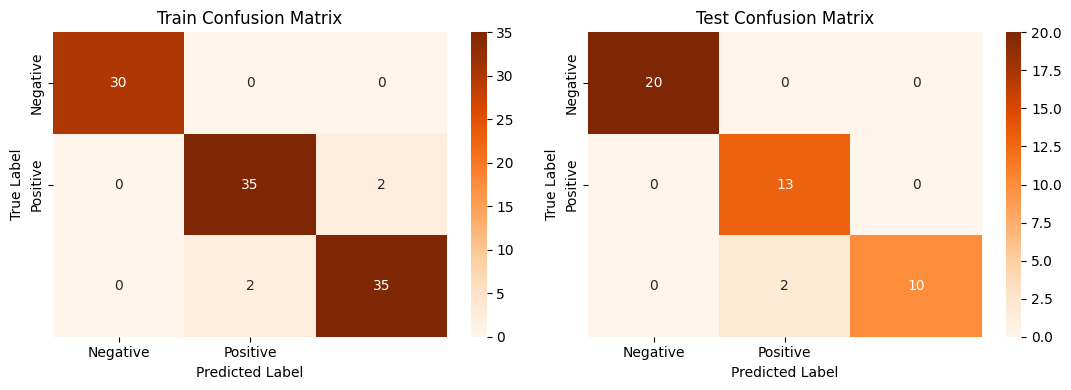


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  30        |
| 1            |    0.945946 | 0.945946 |   0.945946 |  37        |
| 2            |    0.945946 | 0.945946 |   0.945946 |  37        |
| accuracy     |    0.961538 | 0.961538 |   0.961538 |   0.961538 |
| macro avg    |    0.963964 | 0.963964 |   0.963964 | 104        |
| weighted avg |    0.961538 | 0.961538 |   0.961538 | 104        |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 20        |
| 1            |    0.866667 | 1        |   0.928571 | 13        |
| 2            |    1        | 0.833333 |   0.909091 | 12        |
| accuracy     |    0.955556 | 0.955556 |   0.955556 |  0.9555

In [59]:


# ML Model - 6 Implementation
nb_model = GaussianNB()

# Model is trained (fit) and predicted in the evaluate model
     


# Visualizing evaluation Metric Score chart
nb_score = evaluate_model(nb_model, x_train, x_test, y_train, y_test)

In [60]:

# Updated Evaluation metric Score Chart
score['Naive Bayes'] = nb_score
score

,Logistic regression,Decision Tree,Decision Tree tuned,Random Forest,Random Forest tuned,SVM,SVM tuned,XGB,XGB tuned,Naive Bayes
Precision Train,0.952148,1.000000,0.962468,1.000000,0.961538,0.961538,0.952148,1.000000,0.981755,0.961538
Precision Test,0.979365,0.934488,0.961481,0.961481,0.961481,1.000000,0.979365,0.979365,0.979365,0.961481
Recall Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538,0.951923,1.000000,0.980769,0.961538
Recall Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000,0.977778,0.977778,0.977778,0.955556
Accuracy Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538,0.951923,1.000000,0.980769,0.961538
Accuracy Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000,0.977778,0.977778,0.977778,0.955556
F1 macro Train,0.951914,1.000000,0.961510,1.000000,0.961538,0.961538,0.951914,1.000000,0.980755,0.961538
F1 macro Test,0.977706,0.933119,0.955123,0.955123,0.955123,1.000000,0.977706,0.977706,0.977706,0.955123


2. Cross- Validation & Hyperparameter Tuning


In [61]:

# ML Model - 6 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Define the hyperparameter grid
param_grid = {'var_smoothing': np.logspace(0,-9, num=100)}

# Initialize the model
naive = GaussianNB()

# repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=4, n_repeats=4, random_state=0)

# Initialize GridSearchCV
GridSearch = GridSearchCV(naive, param_grid, cv=rskf, n_jobs=-1)

# Fit the GridSearchCV to the training data
GridSearch.fit(x_train, y_train)

# Select the best hyperparameters
best_params = GridSearch.best_params_
print("Best hyperparameters: ", best_params)

Best hyperparameters:  {'var_smoothing': np.float64(0.0012328467394420659)}



Confusion Matrix:


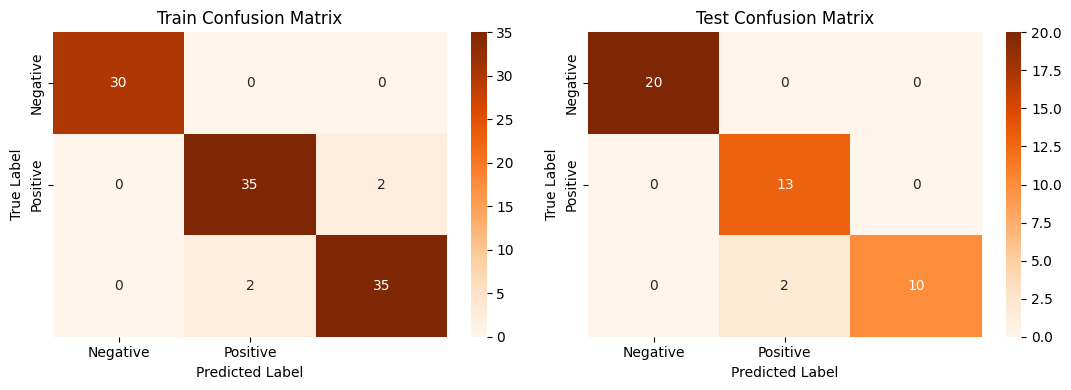


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  30        |
| 1            |    0.945946 | 0.945946 |   0.945946 |  37        |
| 2            |    0.945946 | 0.945946 |   0.945946 |  37        |
| accuracy     |    0.961538 | 0.961538 |   0.961538 |   0.961538 |
| macro avg    |    0.963964 | 0.963964 |   0.963964 | 104        |
| weighted avg |    0.961538 | 0.961538 |   0.961538 | 104        |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 20        |
| 1            |    0.866667 | 1        |   0.928571 | 13        |
| 2            |    1        | 0.833333 |   0.909091 | 12        |
| accuracy     |    0.955556 | 0.955556 |   0.955556 |  0.9555

In [62]:

# Initiate model with best parameters
nb_model2 = GaussianNB(var_smoothing = best_params['var_smoothing'])
     

# Visualizing evaluation Metric Score chart
nb2_score = evaluate_model(nb_model2, x_train, x_test, y_train, y_test)
     

In [63]:

score['Naive Bayes tuned']= nb2_score


# Updated Evaluation metric Score Chart
score

,Logistic regression,Decision Tree,Decision Tree tuned,Random Forest,Random Forest tuned,SVM,SVM tuned,XGB,XGB tuned,Naive Bayes,Naive Bayes tuned
Precision Train,0.952148,1.000000,0.962468,1.000000,0.961538,0.961538,0.952148,1.000000,0.981755,0.961538,0.961538
Precision Test,0.979365,0.934488,0.961481,0.961481,0.961481,1.000000,0.979365,0.979365,0.979365,0.961481,0.961481
Recall Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538,0.951923,1.000000,0.980769,0.961538,0.961538
Recall Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000,0.977778,0.977778,0.977778,0.955556,0.955556
Accuracy Train,0.951923,1.000000,0.961538,1.000000,0.961538,0.961538,0.951923,1.000000,0.980769,0.961538,0.961538
Accuracy Test,0.977778,0.933333,0.955556,0.955556,0.955556,1.000000,0.977778,0.977778,0.977778,0.955556,0.955556
F1 macro Train,0.951914,1.000000,0.961510,1.000000,0.961538,0.961538,0.951914,1.000000,0.980755,0.961538,0.961538
F1 macro Test,0.977706,0.933119,0.955123,0.955123,0.955123,1.000000,0.977706,0.977706,0.977706,0.955123,0.955123
